# 05 — Production Monitoring (2026 data)
Simula monitoreo de producción usando `data/processed/monitor.parquet` (202601–202604).

**Referencia**: train set (202001–202312)  
**Producción**: monitor set (202601–202604)

Cubre:
- Target drift: default rate mensual vs. baseline de train
- PSI por feature
- Score drift: distribución de probabilidades
- **AUC mensual en producción 2026**
- Evidently AI: DataDriftPreset + TargetDriftPreset
- Dashboard resumen de drift

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yaml
from sklearn.metrics import roc_auc_score

from src.features import prepare_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

PSI_BINS  = 10
PSI_ALERT = 0.2
PSI_WARN  = 0.1

In [2]:
with open('../params.yaml') as f:
    params = yaml.safe_load(f)

PERIOD          = params['features']['period_col']
TARGET          = params['features']['target']
NUMERIC         = params['features']['numeric']
DRIFT_THRESHOLD = params['monitoring']['drift_threshold']
AUC_GATE        = params['model']['auc_threshold']

train_df   = pd.read_parquet(f"../{params['data']['train_path']}")
test_df    = pd.read_parquet(f"../{params['data']['test_path']}")
monitor_df = pd.read_parquet(f"../{params['data']['monitor_path']}")

X_ref, y_ref = prepare_features(train_df,   params_path='../params.yaml')
X_test, y_test = prepare_features(test_df,  params_path='../params.yaml')
X_cur, y_cur = prepare_features(monitor_df, params_path='../params.yaml')

print(f"Train:   {len(train_df):>7,} rows | {train_df[PERIOD].min()}–{train_df[PERIOD].max()}")
print(f"Test:    {len(test_df):>7,} rows | {test_df[PERIOD].min()}–{test_df[PERIOD].max()}")
print(f"Monitor: {len(monitor_df):>7,} rows | {monitor_df[PERIOD].min()}–{monitor_df[PERIOD].max()}")

Train:   631,361 rows | 202001–202312
Test:    316,067 rows | 202401–202512
Monitor:  52,572 rows | 202601–202604


## 1. Cargar modelo
> Intenta MLflow. Si no está disponible entrena LightGBM local como fallback.

In [3]:
import mlflow

MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', params['mlflow']['tracking_uri'])
MODEL_URI  = os.getenv('MODEL_URI', params['api']['model_uri'])
mlflow.set_tracking_uri(MLFLOW_URI)

try:
    pipeline = mlflow.sklearn.load_model(MODEL_URI)
    print(f"Modelo cargado desde MLflow: {MODEL_URI}")
except Exception as e:
    print(f"MLflow no disponible ({e}).\nEntrenando LightGBM local...")
    from lightgbm import LGBMClassifier
    from src.features import build_full_pipeline

    neg, pos = (y_ref == 0).sum(), (y_ref == 1).sum()
    pipeline = build_full_pipeline(
        LGBMClassifier(n_estimators=300, scale_pos_weight=neg / pos, random_state=42, verbosity=-1)
    )
    pipeline.fit(X_ref, y_ref)
    test_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    print(f"Modelo local entrenado  |  Test AUC: {test_auc:.4f}")

MLflow no disponible (API request to endpoint /api/2.0/mlflow/registered-models/get-latest-versions failed with error code 403 != 200. Response body: '').
Entrenando LightGBM local...
Modelo local entrenado  |  Test AUC: 0.9943


## 2. Target drift — default rate mensual

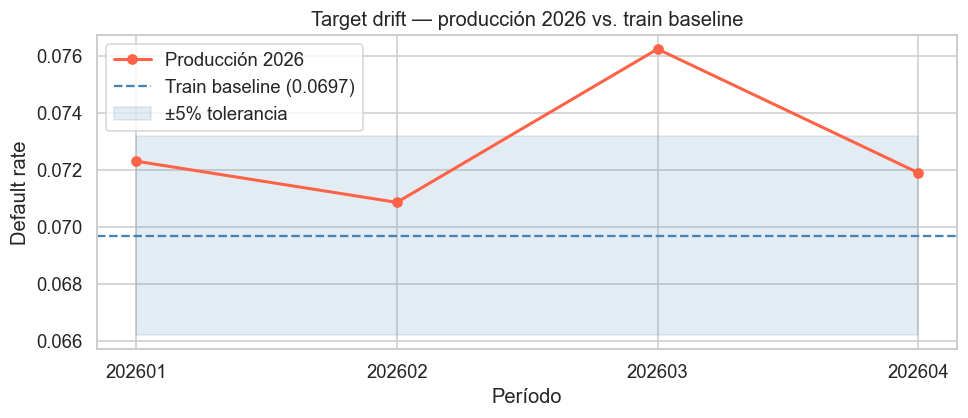


  202601.0: rate=0.0723  Δ=3.75%  [OK]
  202602.0: rate=0.0709  Δ=1.68%  [OK]
  202603.0: rate=0.0762  Δ=9.39%  [ALERT]
  202604.0: rate=0.0719  Δ=3.16%  [OK]


In [4]:
ref_rate = float(y_ref.mean())

monthly_target = (
    monitor_df.assign(y=y_cur.values)
    .groupby(PERIOD)['y'].mean()
    .reset_index()
    .rename(columns={'y': 'default_rate'})
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly_target[PERIOD].astype(str), monthly_target['default_rate'],
        marker='o', color='tomato', linewidth=2, label='Producción 2026')
ax.axhline(ref_rate, color='steelblue', linestyle='--', label=f'Train baseline ({ref_rate:.4f})')
ax.fill_between(
    monthly_target[PERIOD].astype(str),
    ref_rate * (1 - DRIFT_THRESHOLD), ref_rate * (1 + DRIFT_THRESHOLD),
    alpha=0.15, color='steelblue', label=f'±{DRIFT_THRESHOLD*100:.0f}% tolerancia',
)
ax.set_xlabel('Período')
ax.set_ylabel('Default rate')
ax.set_title('Target drift — producción 2026 vs. train baseline')
ax.legend()
plt.tight_layout()
plt.show()

print()
for _, row in monthly_target.iterrows():
    delta = abs(row['default_rate'] - ref_rate) / ref_rate
    status = 'ALERT' if delta > DRIFT_THRESHOLD else 'OK'
    print(f"  {row[PERIOD]}: rate={row['default_rate']:.4f}  Δ={delta:.2%}  [{status}]")

## 3. PSI — Population Stability Index por feature

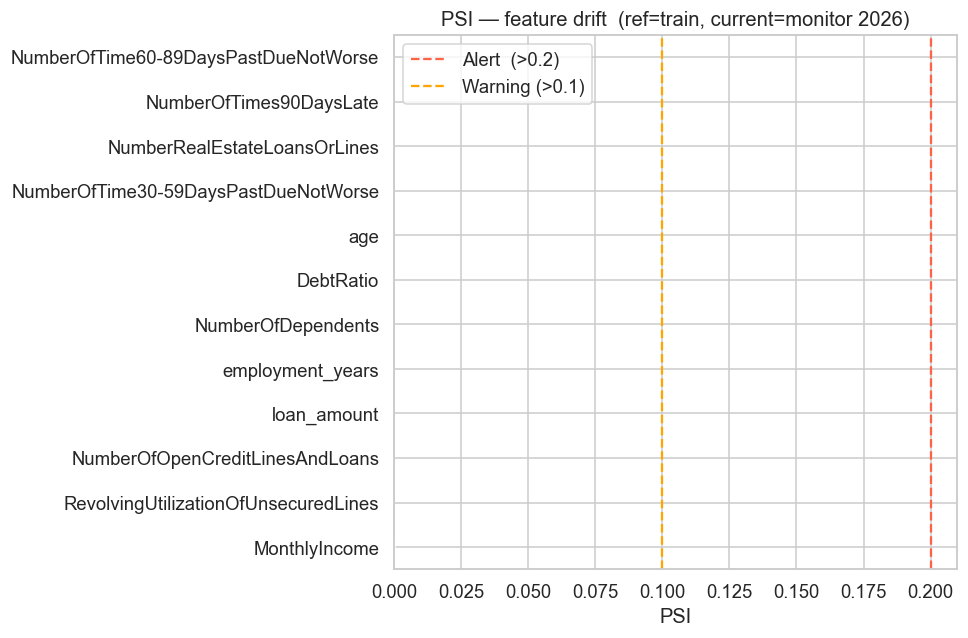


  MonthlyIncome                                 PSI=0.0004  [OK]
  RevolvingUtilizationOfUnsecuredLines          PSI=0.0002  [OK]
  NumberOfOpenCreditLinesAndLoans               PSI=0.0001  [OK]
  loan_amount                                   PSI=0.0001  [OK]
  employment_years                              PSI=0.0001  [OK]
  NumberOfDependents                            PSI=0.0001  [OK]
  DebtRatio                                     PSI=0.0001  [OK]
  age                                           PSI=0.0000  [OK]
  NumberOfTime30-59DaysPastDueNotWorse          PSI=0.0000  [OK]
  NumberRealEstateLoansOrLines                  PSI=0.0000  [OK]
  NumberOfTimes90DaysLate                       PSI=0.0000  [OK]
  NumberOfTime60-89DaysPastDueNotWorse          PSI=0.0000  [OK]


In [5]:
def compute_psi(ref: pd.Series, cur: pd.Series, bins: int = 10) -> float:
    ref_clean, cur_clean = ref.dropna(), cur.dropna()
    bp = np.unique(np.percentile(ref_clean, np.linspace(0, 100, bins + 1)))
    if len(bp) < 2:
        return 0.0
    eps = 1e-4
    ref_pct = np.histogram(ref_clean, bins=bp)[0] / len(ref_clean) + eps
    cur_pct = np.histogram(cur_clean, bins=bp)[0] / len(cur_clean) + eps
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


psi_results = {c: compute_psi(X_ref[c], X_cur[c], PSI_BINS) for c in NUMERIC if c in X_ref.columns}
psi_series  = pd.Series(psi_results).sort_values(ascending=False)

colors = ['tomato' if v > PSI_ALERT else ('orange' if v > PSI_WARN else 'steelblue')
          for v in psi_series.values]

fig, ax = plt.subplots(figsize=(9, 6))
psi_series.plot.barh(ax=ax, color=colors)
ax.axvline(PSI_ALERT, color='tomato',  linestyle='--', label=f'Alert  (>{PSI_ALERT})')
ax.axvline(PSI_WARN,  color='orange',  linestyle='--', label=f'Warning (>{PSI_WARN})')
ax.set_title('PSI — feature drift  (ref=train, current=monitor 2026)')
ax.set_xlabel('PSI')
ax.legend()
plt.tight_layout()
plt.show()

print()
for feat, psi in psi_series.items():
    level = 'ALERT' if psi > PSI_ALERT else ('WARNING' if psi > PSI_WARN else 'OK')
    print(f"  {feat:<45} PSI={psi:.4f}  [{level}]")

## 4. Features más drifteadas — distribución antes/después

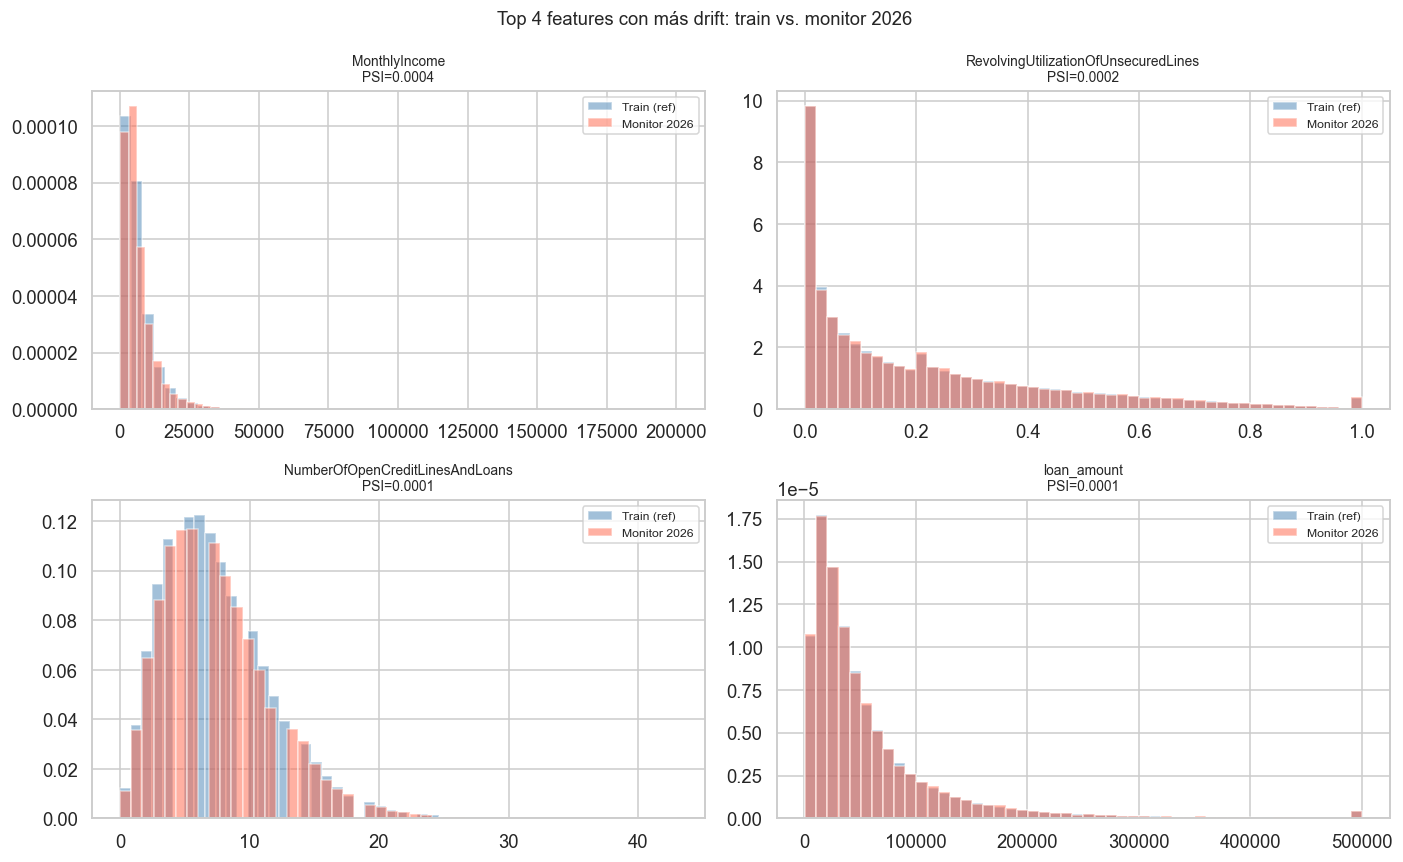

In [6]:
top_drift = psi_series.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(top_drift):
    axes[i].hist(X_ref[col].dropna(), bins=50, alpha=0.5, label='Train (ref)',   color='steelblue', density=True)
    axes[i].hist(X_cur[col].dropna(), bins=50, alpha=0.5, label='Monitor 2026',  color='tomato',    density=True)
    axes[i].set_title(f'{col}\nPSI={psi_results[col]:.4f}', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Top 4 features con más drift: train vs. monitor 2026', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Score drift — distribución de probabilidades

Score PSI (test 2024-2025 vs. monitor 2026): 0.0002


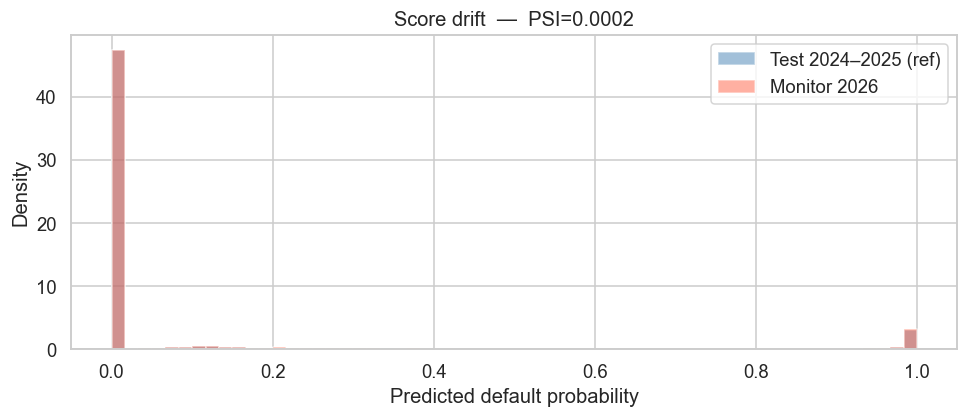

In [7]:
scores_test = pipeline.predict_proba(X_test)[:, 1]
scores_cur  = pipeline.predict_proba(X_cur)[:, 1]

psi_score = compute_psi(pd.Series(scores_test), pd.Series(scores_cur), PSI_BINS)
print(f"Score PSI (test 2024-2025 vs. monitor 2026): {psi_score:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_test, bins=60, alpha=0.5, label='Test 2024–2025 (ref)', color='steelblue', density=True)
ax.hist(scores_cur,  bins=60, alpha=0.5, label='Monitor 2026',         color='tomato',    density=True)
ax.set_xlabel('Predicted default probability')
ax.set_ylabel('Density')
ax.set_title(f'Score drift  —  PSI={psi_score:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

## 6. AUC mensual — producción 2026

AUC mensual en producción 2026:
  202601.0: AUC=0.9945  [PASS ✓]
  202602.0: AUC=0.9943  [PASS ✓]
  202603.0: AUC=0.9937  [PASS ✓]
  202604.0: AUC=0.9936  [PASS ✓]


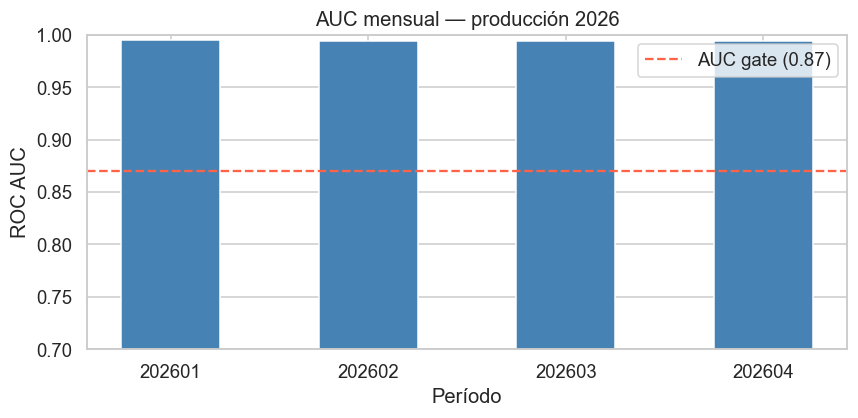

In [8]:
monitor_eval = monitor_df[[PERIOD]].copy()
monitor_eval['score']  = scores_cur
monitor_eval['y_true'] = y_cur.values

monthly_auc = (
    monitor_eval.groupby(PERIOD)
    .apply(lambda g: roc_auc_score(g['y_true'], g['score']) if g['y_true'].nunique() > 1 else float('nan'))
    .rename('auc')
    .reset_index()
)

print("AUC mensual en producción 2026:")
for _, row in monthly_auc.iterrows():
    status = 'PASS ✓' if row['auc'] >= AUC_GATE else 'FAIL ✗'
    print(f"  {row[PERIOD]}: AUC={row['auc']:.4f}  [{status}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_auc[PERIOD].astype(str), monthly_auc['auc'],
       color=['steelblue' if v >= AUC_GATE else 'tomato' for v in monthly_auc['auc']],
       width=0.5)
ax.axhline(AUC_GATE, color='tomato', linestyle='--', linewidth=1.5, label=f'AUC gate ({AUC_GATE})')
ax.set_xlabel('Período')
ax.set_ylabel('ROC AUC')
ax.set_title('AUC mensual — producción 2026')
ax.set_ylim(0.7, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evidently AI — Data drift report

In [9]:
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, TargetDriftPreset

    REPORT_PATH = '../reports/drift_report_notebook.html'
    os.makedirs('../reports', exist_ok=True)

    reference = X_ref.copy()
    reference[TARGET] = y_ref.values
    current = X_cur.copy()
    current[TARGET] = y_cur.values

    report = Report(metrics=[DataDriftPreset(), TargetDriftPreset()])
    report.run(reference_data=reference, current_data=current)
    report.save_html(REPORT_PATH)
    print(f"Reporte guardado → {REPORT_PATH}")

    try:
        report.show(mode='inline')
    except Exception:
        from IPython.display import IFrame, display
        display(IFrame(src=REPORT_PATH, width='100%', height=800))

except ImportError:
    print("evidently no instalado. Corre: pip install evidently")
except Exception as e:
    print(f"Evidently error: {e}")

evidently no instalado. Corre: pip install evidently


## 8. Resumen de drift

In [10]:
rows = []
for feat, psi in psi_series.items():
    level = 'ALERT' if psi > PSI_ALERT else ('WARNING' if psi > PSI_WARN else 'OK')
    rows.append({'Feature': feat, 'PSI': round(psi, 4), 'Status': level})

summary_df = pd.DataFrame(rows)

def _color(val):
    return {'ALERT': 'background-color: #ffcccc',
            'WARNING': 'background-color: #fff3cc'}.get(val, '')

summary_df.style.map(_color, subset=['Status'])

,Feature,PSI,Status
0,MonthlyIncome,0.000400,OK
1,RevolvingUtilizationOfUnsecuredLines,0.000200,OK
2,NumberOfOpenCreditLinesAndLoans,0.000100,OK
3,loan_amount,0.000100,OK
4,employment_years,0.000100,OK
5,NumberOfDependents,0.000100,OK
6,DebtRatio,0.000100,OK
7,age,0.000000,OK
8,NumberOfTime30-59DaysPastDueNotWorse,0.000000,OK
9,NumberRealEstateLoansOrLines,0.000000,OK
